In [ ]:
from __future__ import annotations

import json
import pickle
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from tqdm import tqdm

from voids.generators import generate_macro_micro_blobs_matrix
from voids.io import VolumeData, save_volume_bundle

In [28]:
def _find_project_root() -> Path:
    cwd = Path.cwd().resolve()

    for candidate in (cwd, *cwd.parents):
        if (candidate / "mkdocs.yml").exists() and (candidate / "notebooks").exists():
            return candidate

    return cwd


def _relative_to_root(path: Path, root: Path) -> str:
    try:
        return str(path.relative_to(root))
    except ValueError:
        return str(path)

In [29]:


project_root = _find_project_root()

# Pasta onde serão salvos os arquivos
output_dir = (
    project_root/ "notebooks_final"/ "Final_jair_final" / "final_data_final"
)

# Cria a pasta caso ela não exista
output_dir.mkdir(parents=True, exist_ok=True)

print(f"Projeto: {project_root}")
print(f"Arquivos serão salvos em:\n{output_dir.resolve()}")

Projeto: /home/dairsonalbert/Pos-Graduacao-LNCC/2026_2/EDP/trabalho_final_implimentacao/voids
Arquivos serão salvos em:
/home/dairsonalbert/Pos-Graduacao-LNCC/2026_2/EDP/trabalho_final_implimentacao/voids/notebooks_final/Final_jair_final/final_data_final


In [30]:
shape = (200, 200)
macro_blobiness = 1.4
micropore_blobiness = 10.0
max_tries = 30
periodic = True
voxel_size_m = (40.0e-6,40.0e-6,)
length_units = {"length": "m"}

In [31]:
N_SAMPLES = 100

np.random.seed(52)

macro_range = (0.05, 0.45)
micro_range = (0.02, 0.30)

macro_porosities = np.random.uniform(
    macro_range[0],
    macro_range[1],
    N_SAMPLES,
)

micro_porosities = np.random.uniform(
    micro_range[0],
    micro_range[1],
    N_SAMPLES,
)

for i in range(N_SAMPLES):

    if macro_porosities[i] < micro_porosities[i]:
        (
            macro_porosities[i],
            micro_porosities[i],
        ) = (
            micro_porosities[i],
            macro_porosities[i],
        )

print(f"Gerando {N_SAMPLES} amostras...")

print(
    f"Range macro: {macro_porosities.min():.3f} - {macro_porosities.max():.3f}"
)

print(
    f"Range micro: {micro_porosities.min():.3f} - {micro_porosities.max():.3f}"
)

Gerando 100 amostras...
Range macro: 0.076 - 0.448
Range micro: 0.025 - 0.299


#### Inicialização das estruturas

In [32]:
generated_cases = []

case_summaries = []

failed_attempts = 0

start_time = time.time()

#### Geração das amostras

In [33]:
for idx in tqdm(range(N_SAMPLES), desc="Gerando amostras"):

    macro_target = macro_porosities[idx]
    micro_target = micro_porosities[idx]

    try:

        case = generate_macro_micro_blobs_matrix(
            shape=shape,
            macro_porosity=macro_target,
            matrix_microporosity=micro_target,
            macro_blobiness=macro_blobiness,
            micropore_blobiness=micropore_blobiness,
            seed_start=2026 + idx,
            max_tries=max_tries,
            periodic=periodic,
        )

        target_total = (
            macro_target
            + (1.0 - macro_target) * micro_target
        )

        summary = {
            "case_id": idx,
            "target_macro_porosity": macro_target,
            "target_micro_porosity": micro_target,
            "target_total_porosity": target_total,
            "realized_total_porosity": case.porosity,
            "realized_macro_porosity": case.macro_porosity,
            "realized_matrix_microporosity": case.matrix_microporosity,
            "realized_total_microporosity": case.total_microporosity,
            "macro_seed": case.metadata["macro_seed"],
            "micropore_seed": case.metadata["micropore_seed"],
            "shape": case.shape,
        }

        generated_cases.append(case)
        case_summaries.append(summary)

    except Exception as e:

        failed_attempts += 1

        print(f"\nFalha no caso {idx}: {e}")

        continue

end_time = time.time()

total_time = end_time - start_time

Gerando amostras: 100%|██████████| 100/100 [00:00<00:00, 204.37it/s]


##### Resumo da geração

In [34]:
print("\n--- Geração concluída ---")

print(f"Casos gerados: {len(generated_cases)}")

print(f"Falhas: {failed_attempts}")

print(f"Tempo total: {total_time:.2f} s")

print(
    f"Média por caso: {total_time/len(generated_cases):.2f} s"
)


--- Geração concluída ---
Casos gerados: 100
Falhas: 0
Tempo total: 0.50 s
Média por caso: 0.00 s


## Salvando os dados  em .pkl para Upscaling 

In [35]:

# shape = (Ny, Nx) em número de voxels; voxel_size_m = (dx, dy) em metros/voxel
Ny_shape, Nx_shape = shape
Lx_m = Nx_shape * voxel_size_m[0]   # comprimento físico em x (metros)
Ly_m = Ny_shape * voxel_size_m[1]   # comprimento físico em y (metros)

print(f"Domínio físico: Lx = {Lx_m*1e3:.3f} mm, Ly = {Ly_m*1e3:.3f} mm")
print(f"Voxel: {voxel_size_m[0]*1e6:.1f} x {voxel_size_m[1]*1e6:.1f} um")

with open(output_dir / "training_data_3000.pkl", "wb") as f:

    pickle.dump(
        {
            "cases": generated_cases,
            "summaries": case_summaries,
            "metadata": {
                "n_samples": len(generated_cases),
                "shape": shape,
                "macro_range": macro_range,
                "micro_range": micro_range,
                "generation_time": total_time,
                # --- Escala física (necessária para o cálculo de Keff em unidades reais) ---
                "voxel_size_m": voxel_size_m,
                "length_units": length_units,
                "Lx_m": Lx_m,
                "Ly_m": Ly_m,
            },
        },
        f,
    )


with open(output_dir / "case_summaries_3000.json", "w") as f:

    json.dump(case_summaries, f, indent=2)


Domínio físico: Lx = 8.000 mm, Ly = 8.000 mm
Voxel: 40.0 x 40.0 um


##### conversão para Numpy

In [36]:
void_arrays = np.array(
    [
        case.void.astype(np.float32)
        for case in generated_cases
    ]
)

macro_arrays = np.array(
    [
        case.macro_void.astype(np.float32)
        for case in generated_cases
    ]
)

micro_arrays = np.array(
    [
        case.micropore_void.astype(np.float32)
        for case in generated_cases
    ]
)

np.save( output_dir / "void_arrays_3000.npy", void_arrays,)

np.save( output_dir / "macro_arrays_3000.npy", macro_arrays)

np.save( output_dir / "micro_arrays_3000.npy", micro_arrays)

targets = np.array(
    [
        [
            s["target_macro_porosity"],
            s["target_micro_porosity"],
            s["target_total_porosity"],
        ]
        for s in case_summaries
    ]
)

np.save(output_dir / "targets_3000.npy",targets)

##### Visualização da distribuição das porosidades

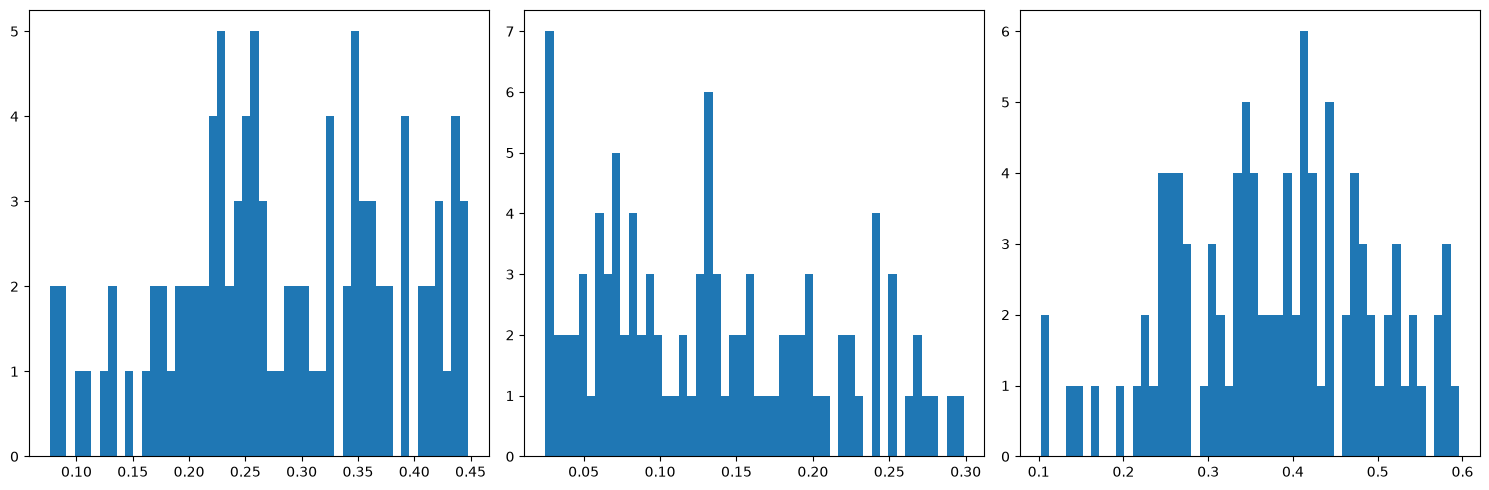

In [37]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
)

macro_realized = [
    s["realized_macro_porosity"]
    for s in case_summaries
]

micro_realized = [
    s["realized_matrix_microporosity"]
    for s in case_summaries
]

total_realized = [
    s["realized_total_porosity"]
    for s in case_summaries
]

axes[0].hist(macro_realized, bins=50)

axes[1].hist(micro_realized, bins=50)

axes[2].hist(total_realized, bins=50)

plt.tight_layout()

plt.savefig(
    output_dir / "porosity_distributionn_3000.png",
    dpi=150,
)

plt.show()

##### Visualizar exemplos

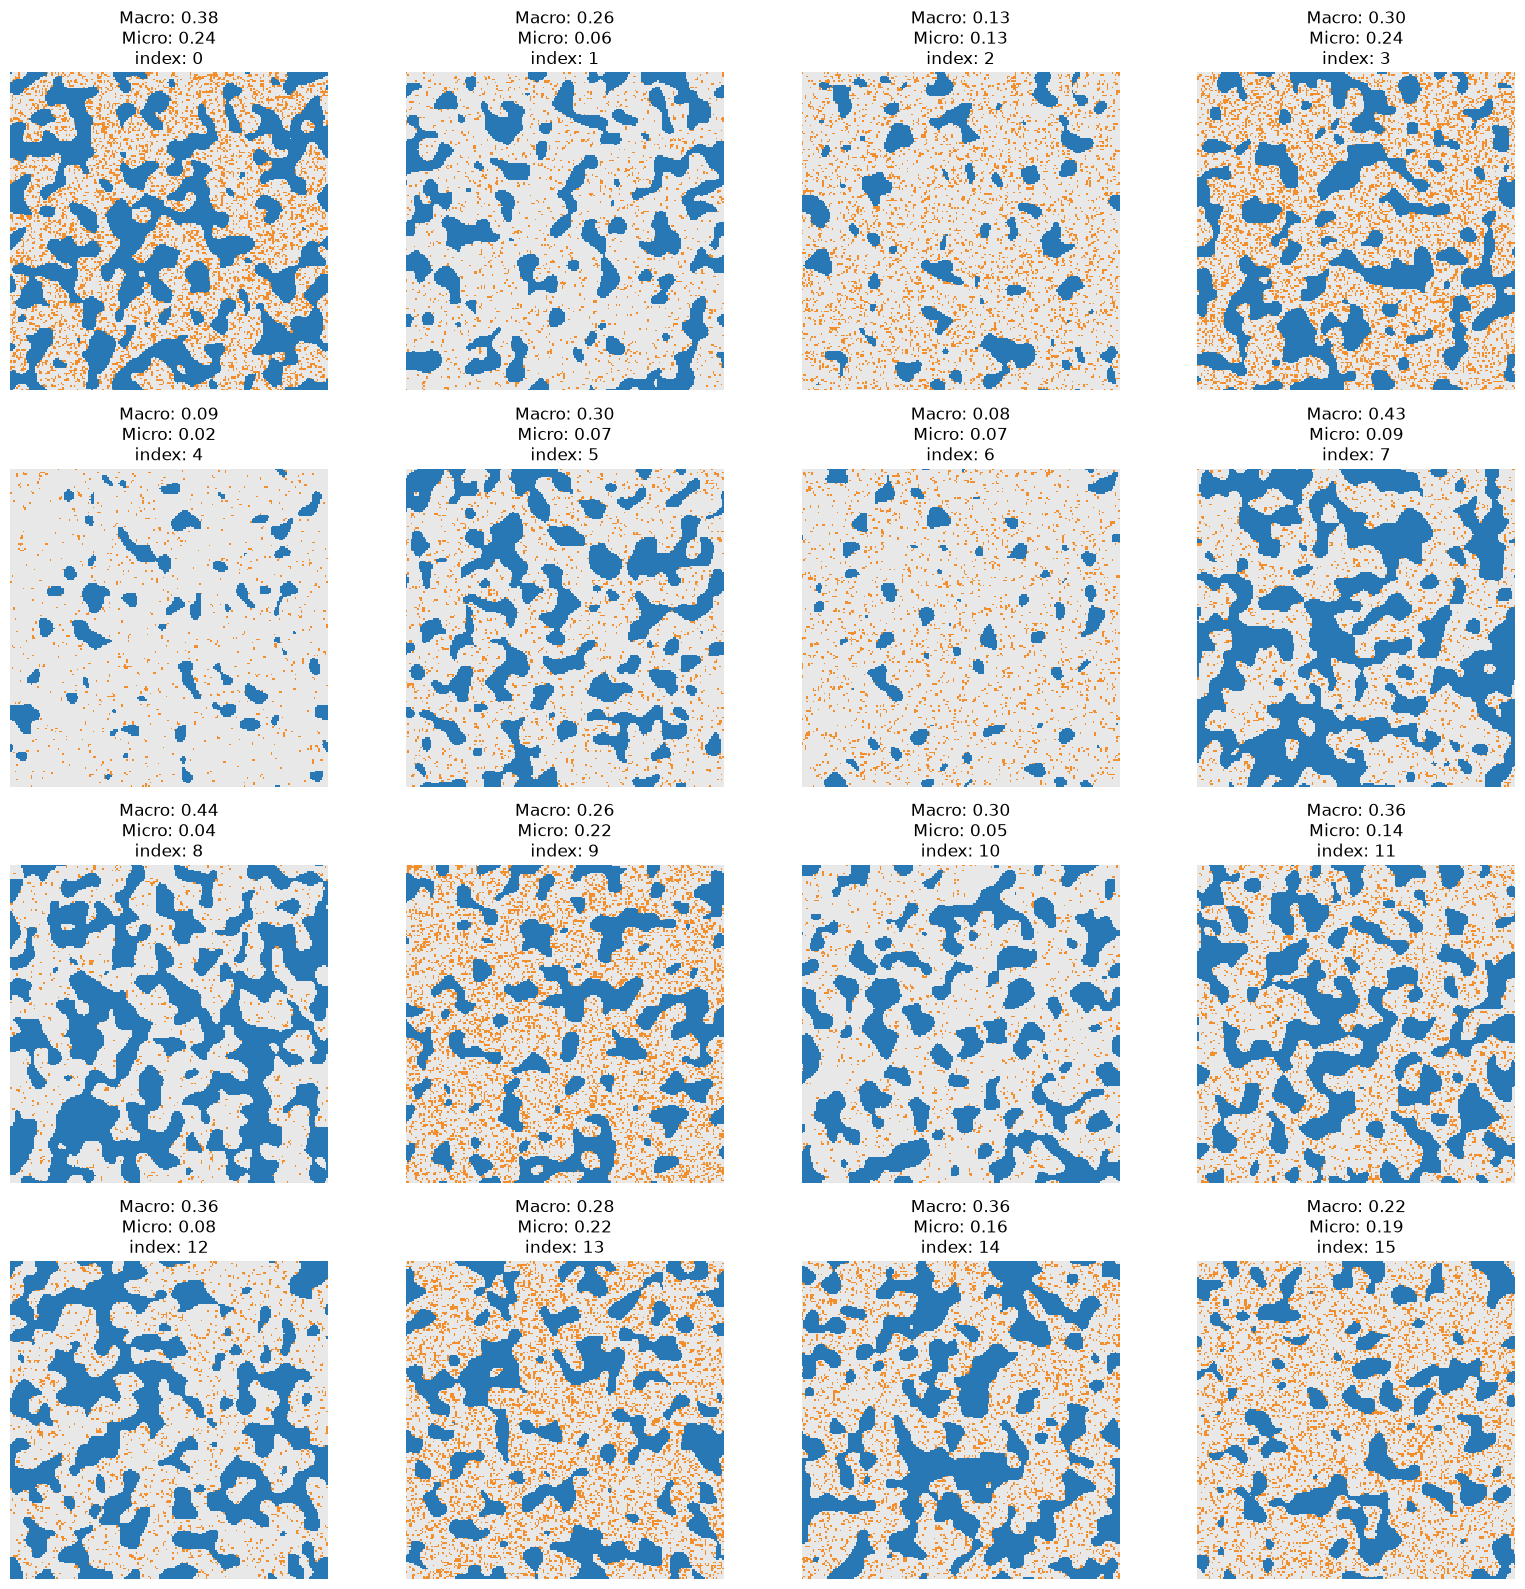

In [45]:
fig, axes = plt.subplots(4, 4, figsize=(16, 16),)

sample_indices = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14,15,16,]


phase_cmap = ListedColormap(
    [
        "#e8e8e8",
        "#2878b5",
        "#f28e2b",
    ]
)

for i, ax in enumerate(axes.flat):

    idx = sample_indices[i]

    case = generated_cases[idx]

    summary = case_summaries[idx]

    phase = np.zeros(case.shape, dtype=np.uint8)

    phase[case.macro_void] = 1

    phase[case.micropore_void] = 2

    ax.imshow(
        phase,
        cmap=phase_cmap,
        vmin=0,
        vmax=2,
        interpolation="nearest",
    )

    ax.set_title(
        f"Macro: {summary['target_macro_porosity']:.2f}\n"
        f"Micro: {summary['target_micro_porosity']:.2f}\n"
        f"index: {idx}"
    )

    ax.set_axis_off()

plt.tight_layout()

plt.savefig(
    output_dir / "sample_visualization_3000.png",
    dpi=150,
)

plt.show()

# Abrir Data para ver se está tudo conforme

In [39]:


with open(output_dir / "training_data_3000.pkl", "rb") as f:
    data = pickle.load(f)

for i in range(len(data["cases"])):
    case = data["cases"][i]
    summary = data["summaries"][i]
    print(f"\nCaso {summary['case_id']}:")
    print(f"Target Macro Porosity: {summary['target_macro_porosity']:.4f}")
    print(f"Target Micro Porosity: {summary['target_micro_porosity']:.4f}")
    print(f"Realized Macro Porosity: {summary['realized_macro_porosity']:.4f}")
    print(f"Realized Micro Porosity: {summary['realized_matrix_microporosity']:.4f}")
    print(f"Realized Total Porosity: {summary['realized_total_porosity']:.4f}")


Caso 0:
Target Macro Porosity: 0.3792
Target Micro Porosity: 0.2384
Realized Macro Porosity: 0.3792
Realized Micro Porosity: 0.2384
Realized Total Porosity: 0.5272

Caso 1:
Target Macro Porosity: 0.2576
Target Micro Porosity: 0.0604
Realized Macro Porosity: 0.2576
Realized Micro Porosity: 0.0604
Realized Total Porosity: 0.3024

Caso 2:
Target Macro Porosity: 0.1343
Target Micro Porosity: 0.1318
Realized Macro Porosity: 0.1343
Realized Micro Porosity: 0.1318
Realized Total Porosity: 0.2485

Caso 3:
Target Macro Porosity: 0.2974
Target Micro Porosity: 0.2431
Realized Macro Porosity: 0.2974
Realized Micro Porosity: 0.2431
Realized Total Porosity: 0.4682

Caso 4:
Target Macro Porosity: 0.0893
Target Micro Porosity: 0.0249
Realized Macro Porosity: 0.0893
Realized Micro Porosity: 0.0250
Realized Total Porosity: 0.1120

Caso 5:
Target Macro Porosity: 0.2981
Target Micro Porosity: 0.0669
Realized Macro Porosity: 0.2980
Realized Micro Porosity: 0.0669
Realized Total Porosity: 0.3450

Caso 6:
T

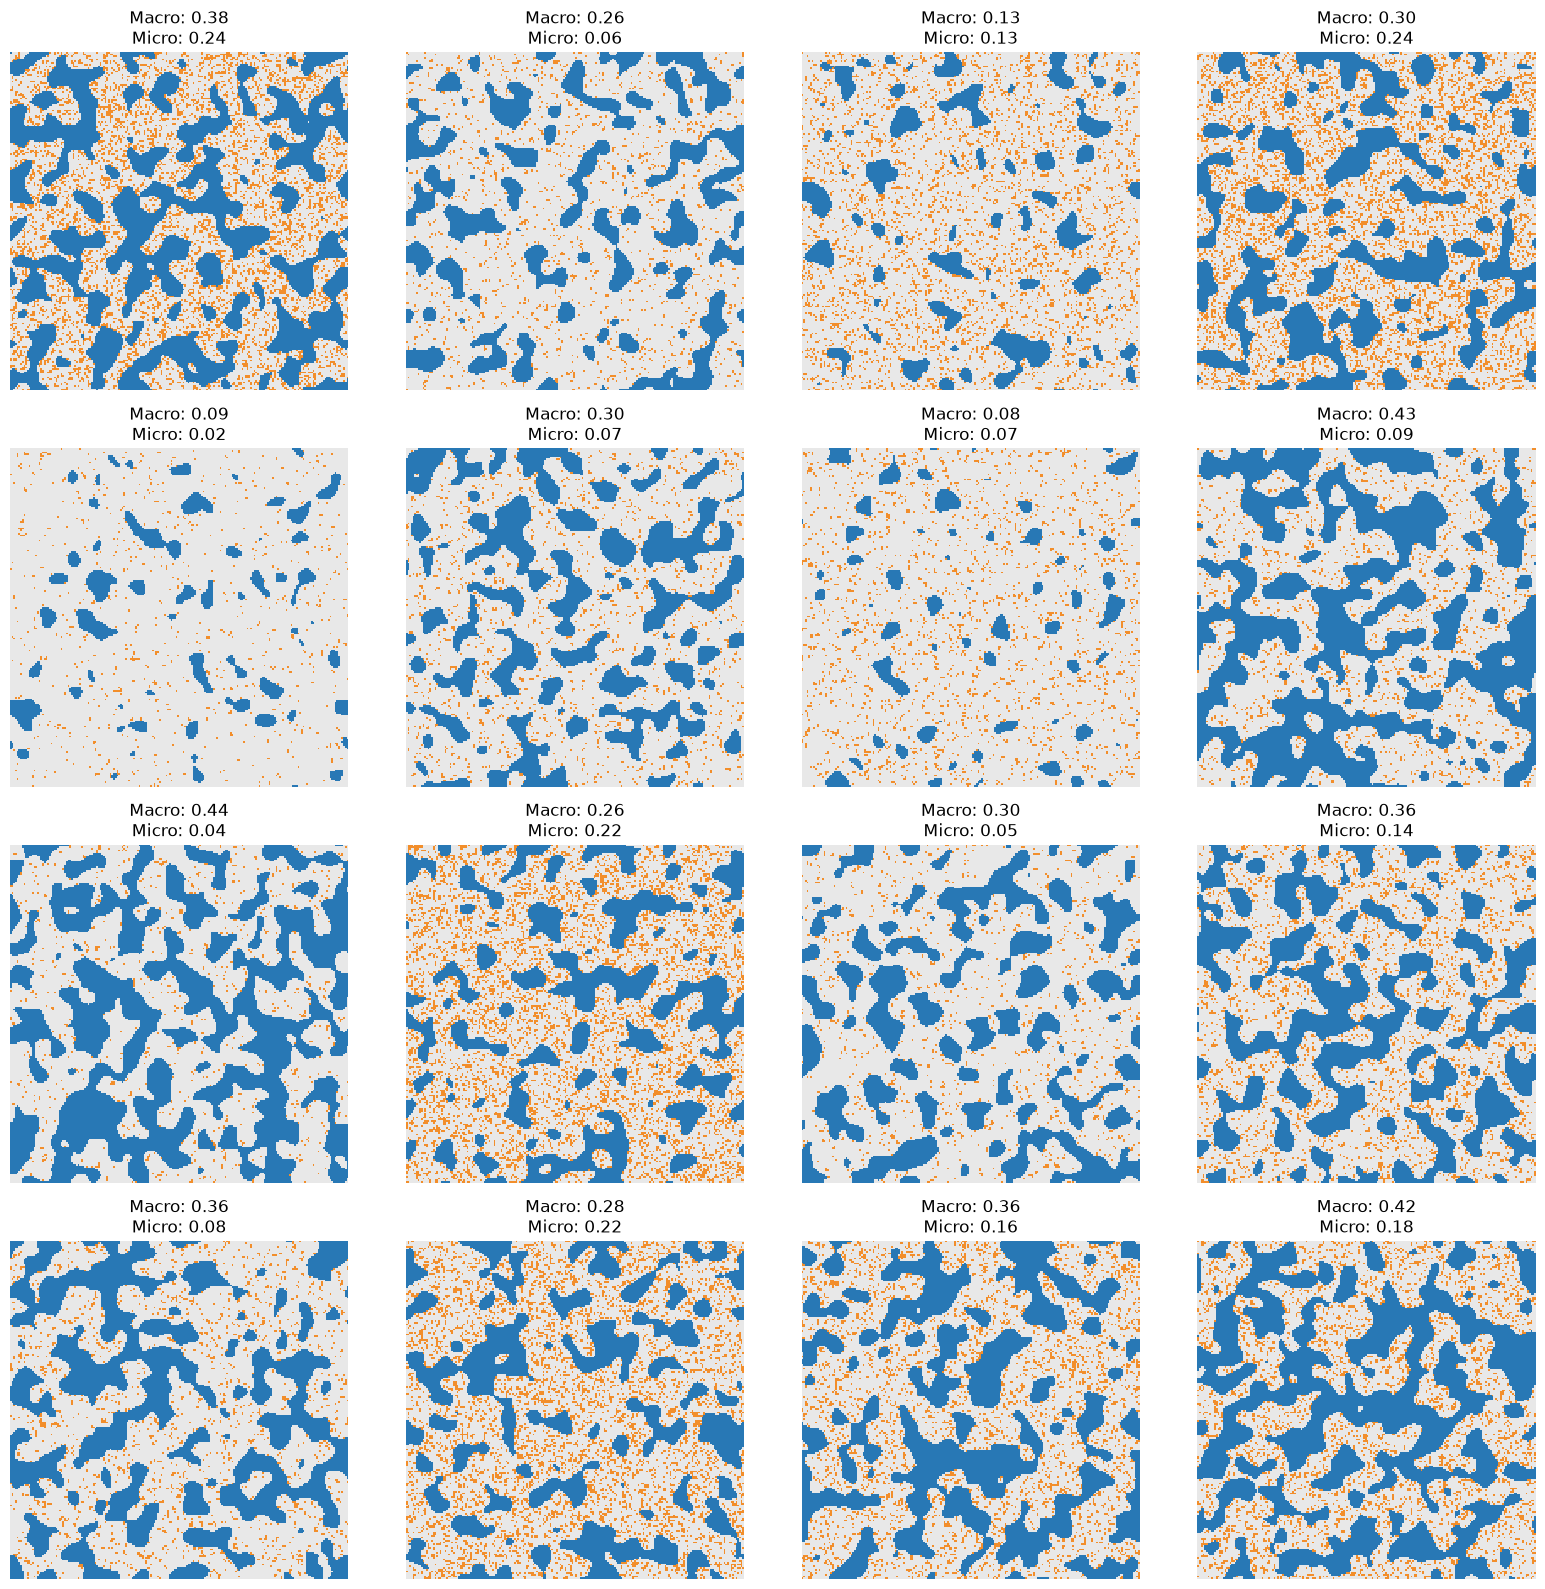

In [40]:
fig, axes = plt.subplots(4,4,figsize=(16, 16),)

sample_indices = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 16]


phase_cmap = ListedColormap(
    [
        "#e8e8e8",
        "#2878b5",
        "#f28e2b",
    ]
)

for i, ax in enumerate(axes.flat):

    idx = sample_indices[i]

    case = data["cases"][idx]

    summary = data["summaries"][idx]

    phase = np.zeros(case.shape, dtype=np.uint8)

    phase[case.macro_void] = 1

    phase[case.micropore_void] = 2

    ax.imshow(
        phase,
        cmap=phase_cmap,
        vmin=0,
        vmax=2,
        interpolation="nearest",
    )

    ax.set_title(
        f"Macro: {summary['target_macro_porosity']:.2f}\n"
        f"Micro: {summary['target_micro_porosity']:.2f}"
    )

    ax.set_axis_off()

plt.tight_layout()

plt.savefig(
    output_dir / "sample_visualization_3000.png",
    dpi=150,
)

plt.show()